# Correlation of ROIs per field

- recently ROIs of AC data very small
- could be that a single dendrite is splitt into multiple ROIs
- notebook aims to check whether sinlge ROIs can be merged into a bigger ROI
- what is required figure-wise:
    - example field (23.10.2025, XY4)
    - heatmap of all traces from that field (gChirp, C1 only)
    - correlation matrix of all traces
    - distance matrix of all traces
        - both preferably also annotated on the image for visual inspection

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Create access to djimaging database

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-11-10 10:34:56,041][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-11-10 10:34:56,118][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

## Activate Schema

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Example field (23.10.2025, XY4)

In [13]:
# Define field and date
field = "XY4"
date = datetime.date(2025, 10, 23)
condition = "C1"
stimulus = "gChirp"

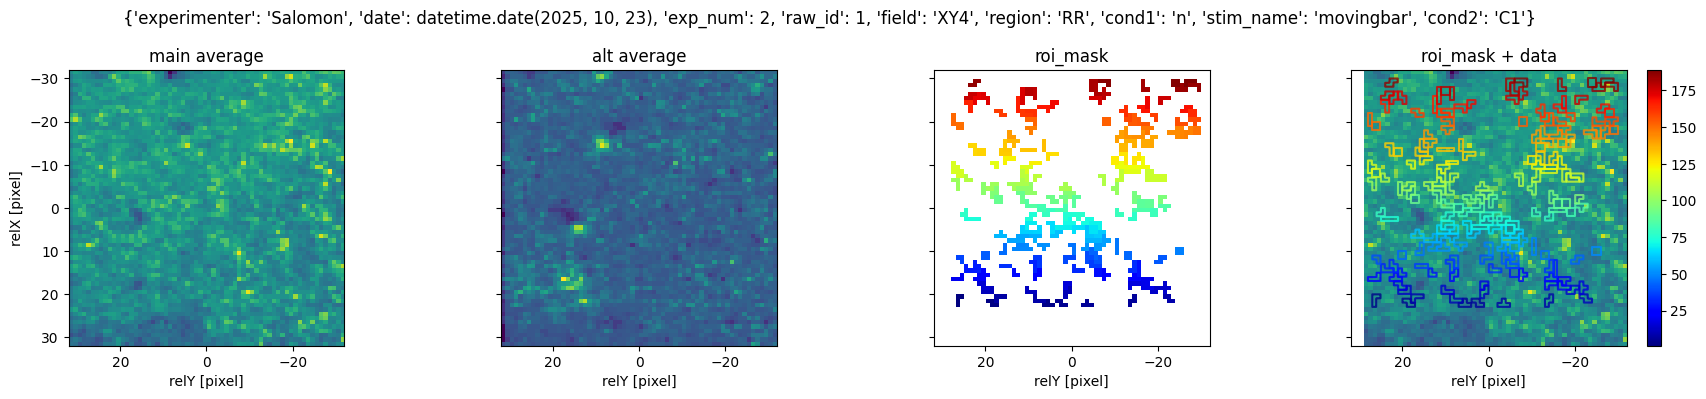

In [14]:
(RoiMask() & {"date": date, "cond2": condition, "stim_name": stimulus, "field": field}).plot1()

plt.savefig("plots/20251023/images/M1_RR_XY4_gChirp_roimask_image.png",
            dpi=300,
            bbox_inches="tight")

# Plot traces, Heatmap from that field

In [15]:
def plot_signals_heatmap_annotated_field(
    signals, ax=None, cb=True, vabsmax=None, symmetric=True,
    field_labels=None, field_colors=None, colorbar_width=0.03,
    legend=True, heatmap_colorbar_position=0.2
):
    """
    Plot a clean heatmap of signals with an optional color-coded bar for field annotations.

    Parameters
    ----------
    signals : array (n_rois, n_timepoints)
        The signal matrix to plot.
    ax : matplotlib axis, optional
        Axis to plot into.
    cb : bool
        Whether to add a colorbar for signal intensity.
    vabsmax : float
        Maximum absolute value for symmetric colormap scaling.
    symmetric : bool
        Whether to use symmetric color limits.
    field_labels : list of str, optional
        Field labels (e.g. 'XY1', 'XY2', ...) for each ROI (row).
    field_colors : dict, optional
        Mapping from field label -> color (e.g. {'XY1': 'red', 'XY2': 'blue', ...}).
        If None, automatically assigns colors.
    colorbar_width : float
        Fractional width of the color bar relative to main heatmap width.
    legend : bool
        Whether to show the legend mapping field colors.
    """
    n_rois, n_timepoints = signals.shape

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, n_rois * 0.03))
    fig = ax.figure  # always need figure for additional axes

    # Determine color limits
    if vabsmax is None:
        vabsmax = np.nanmax(np.abs(signals))

    if symmetric:
        vmin, vmax, cmap = -vabsmax, vabsmax, 'bwr'
    else:
        vmin, vmax, cmap = np.nanmin(signals), np.nanmax(signals), 'viridis'

    # Main heatmap
    im = ax.imshow(
        signals, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap,
        interpolation='none', origin='lower'
    )

    if cb:
        plt.colorbar(im, ax=ax, fraction=0.05, pad=heatmap_colorbar_position, anchor=(1.1, 0.5)) # fraction=0.046, pad=0.08, anchor=(200, 0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # === Field color bar ===
    if field_labels is not None:
        field_labels = np.array(field_labels)

        unique_fields = np.unique(field_labels)
        if field_colors is None:
            cmap_fields = plt.get_cmap('tab10', len(unique_fields))
            field_colors = {f: cmap_fields(i) for i, f in enumerate(unique_fields)}

        # Build color bar as RGBA array
        color_bar = np.array([field_colors[f] for f in field_labels]).reshape(n_rois, 1, 4)

        # Create inset axis for the color bar
        bbox = ax.get_position()
        color_ax = fig.add_axes([
            bbox.x1 + colorbar_width * 0.5,
            bbox.y0,
            colorbar_width * 0.2,
            bbox.height
        ])
        color_ax.imshow(color_bar, aspect='auto', origin='lower')
        color_ax.set_xticks([])
        color_ax.set_yticks([])
        for spine in color_ax.spines.values():
            spine.set_visible(False)

        # Add legend (optional)
        if legend:
            legend_handles = [
                plt.Line2D([0], [0], color=field_colors[f], lw=6, label=f)
                for f in unique_fields
            ]
            ax.legend(
                handles=legend_handles, title="Field",
                bbox_to_anchor=(1.2, 1), loc='upper left', frameon=False
            )

    return ax

In [16]:
# Check dj table for trace data
(Averages() & {"date": date, "field": field, "stim_name": stimulus, "cond2": condition})

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-10-23,2,1,XY4,RR,n,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [17]:
# Fetsch averages from Field XY4 for plotting
average_traces = (Averages() & {"date": date, "field": field, "stim_name": stimulus, "cond2": condition}).fetch("average_norm")
average_traces

array([array([-0.16655343, -0.16798437, -0.16941531, ..., -0.18556922,
              -0.18556922, -0.18556922], shape=(16516,))              ,
       array([-0.19680815, -0.19982622, -0.20284429, ..., -0.11036033,
              -0.11036033, -0.11036033], shape=(16516,))              ,
       array([-0.01979355, -0.020297  , -0.02080045, ...,  0.01932761,
               0.01932761,  0.01932761], shape=(16516,))              ,
       array([-0.00176582,  0.00033109,  0.002428  , ..., -0.09330635,
              -0.09330635, -0.09330635], shape=(16516,))              ,
       array([0.03661222, 0.03584664, 0.03508106, ..., 0.08054709, 0.08054709,
              0.08054709], shape=(16516,))                                    ,
       array([-0.06816119, -0.06641405, -0.06466691, ..., -0.05268679,
              -0.05268679, -0.05268679], shape=(16516,))              ,
       array([-0.26604837, -0.26530031, -0.26455225, ..., -0.32789271,
              -0.32789271, -0.32789271], shape=(16516,)

In [18]:
# Pad traces for equal length
average_traces = math_utils.padded_vstack(average_traces, cval=np.nan)
average_traces
# averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)

array([[-0.16655343, -0.16798437, -0.16941531, ..., -0.18556922,
        -0.18556922, -0.18556922],
       [-0.19680815, -0.19982622, -0.20284429, ..., -0.11036033,
        -0.11036033, -0.11036033],
       [-0.01979355, -0.020297  , -0.02080045, ...,  0.01932761,
         0.01932761,  0.01932761],
       ...,
       [-0.31258748, -0.30997136, -0.30735524, ..., -0.38558896,
        -0.38558896, -0.38558896],
       [-0.17330054, -0.17516074, -0.17702094, ..., -0.17224725,
        -0.17224725, -0.17224725],
       [ 0.03250734,  0.03404895,  0.03559056, ..., -0.10507503,
        -0.10507503, -0.10507503]], shape=(189, 16516))

In [19]:
# Sort traces by correlation value
# From djimaging code
n = average_traces.shape[0]
n

189

In [20]:
sort = True

sort_idxs = trace_utils.argsort_traces(average_traces, ignore_nan=True) if sort else np.arange(n)
sort_idxs

array([ 18, 173, 180, 181, 157, 174, 132, 152, 151, 177, 165, 127, 161,
       179, 186, 146, 178, 166, 133, 140, 160, 169, 118,  13, 135,  47,
         5,   3, 129,   2, 159, 162,   4, 156, 145, 167, 109, 150, 139,
       154, 182,  46, 128,  23,  15,  71, 164,  65,  27,  16, 149,  24,
       170, 153,  17,   1,   9, 112,  37, 176, 113,  51,  11, 185, 148,
       120,  32,  30,  35,  20,  63, 163, 171, 147,  31, 175, 168,  12,
        57,   8, 110, 131,  29, 119,  39,  93, 172,   7,  68,  10, 188,
        80,  14,  26, 138,  87,   6,  38, 130, 102, 183,  55, 187,  88,
        43, 137, 142, 134, 184,  25,  58, 123,  67,  83,  94, 155,  50,
       116,  33,  84, 158,  53, 125, 124,  42,  34,  77, 136, 144, 101,
        21,   0,  19, 141,  56, 111,  40,  48,  49,  62,  66,  44,  73,
        59,  78,  86,  69,  97, 107,  28, 122, 126,  64, 115,  45, 105,
       100,  36,  76, 114,  22,  79,  52, 117,  85,  75,  82,  60,  54,
        96, 106, 121,  61, 143,  92,  70, 108,  41, 104,  89,  9

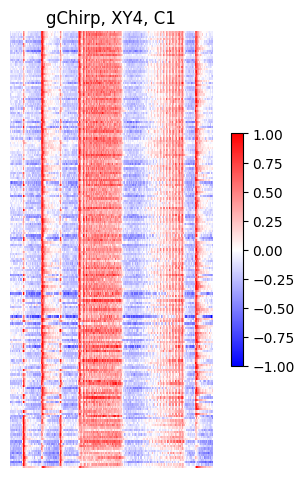

In [21]:
# PLot the heatmap
fig, axs = plt.subplots(1, 1, figsize=(3, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=average_traces[sort_idxs, :],
    ax=axs,
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08)

axs.set_title("gChirp, XY4, C1")

plt.savefig("plots/20251023/traces/M1_RR_XY4_gChirp_heatmap.png",
            dpi=300,
            bbox_inches="tight")

# Plot correlation matrix of gChirp traces

In [22]:
# compute pairwise correlation values for all traces
correlation_coefficients = np.corrcoef(average_traces)
correlation_coefficients = np.round(correlation_coefficients, 2)
correlation_coefficients

array([[1.  , 0.9 , 0.91, ..., 0.74, 0.9 , 0.9 ],
       [0.9 , 1.  , 0.93, ..., 0.58, 0.9 , 0.9 ],
       [0.91, 0.93, 1.  , ..., 0.54, 0.88, 0.89],
       ...,
       [0.74, 0.58, 0.54, ..., 1.  , 0.68, 0.7 ],
       [0.9 , 0.9 , 0.88, ..., 0.68, 1.  , 0.92],
       [0.9 , 0.9 , 0.89, ..., 0.7 , 0.92, 1.  ]], shape=(189, 189))

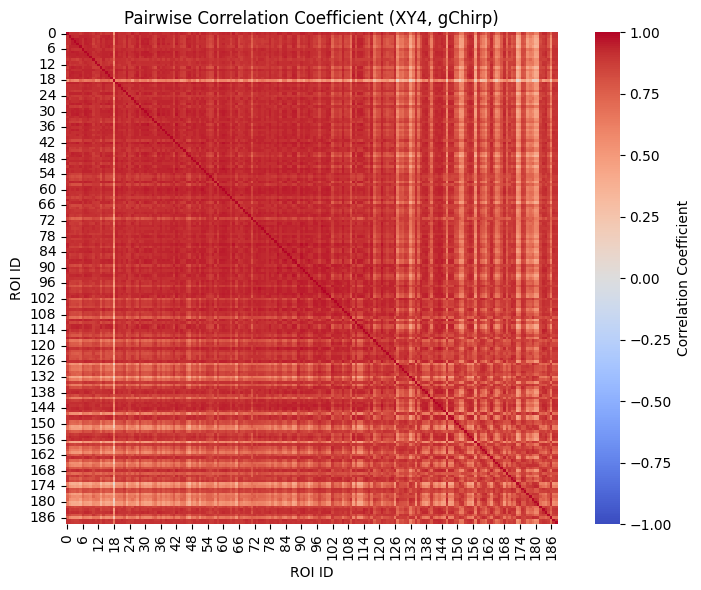

In [23]:
plt.figure(figsize=(8, 6))  # adjust size as needed
sns.heatmap(
    correlation_coefficients, 
    cmap='coolwarm',          # color map (try also 'viridis', 'RdBu_r', etc.)
    vmin=-1, vmax=1,          # correlation ranges from -1 to 1
    square=True,              # make cells square
    #annot=True,               # show correlation values in cells
    fmt=".2f",                # format the annotations
    cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Pairwise Correlation Coefficient (XY4, gChirp)')
plt.xlabel("ROI ID")
plt.ylabel("ROI ID")
plt.tight_layout()
plt.savefig("plots/20251023/traces/M1_RR_XY4_gChirp_heatmap_corrcoef.png",
            dpi=300,
            bbox_inches="tight")

# Distance matrix
- now it will be a bit more complicated, since I can't rely on previous code
- what would be required is the relative position of each ROI in a field
    - could be estimated via there centroid, could be computed via scikit image from the raw ROI image
    - afterwards the distance (d) of two ROIs can be computed via pythagorean theorem with a function from scipy
$$
d = \sqrt{(\Delta x)^2 + (\Delta y)^2} = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

In [24]:
import pickle
import stackview

from scipy.spatial.distance import cdist
from skimage.measure import regionprops
from djimaging.utils.scanm import read_smp_utils

In [25]:
# Load roi data outside of djimaging
file_location = "/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/2/ROIs/M1_RR_n_XY4_chirp_C1_ROIs.pkl"

with open(file_location, "rb") as f:
    rois = pickle.load(f)

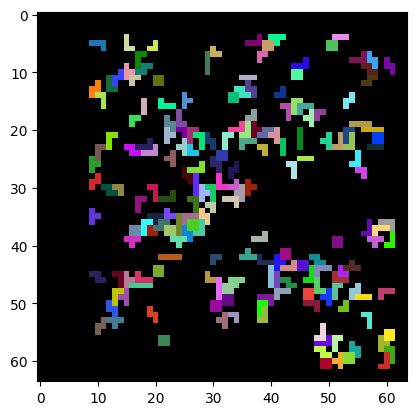

In [26]:
# Show the ROI data
stackview.imshow(rois, labels=True, axes=True)

In [27]:
# Extract region properties
properties = regionprops(rois)
properties[:10]

In [28]:
# Collect centroid data
data = []
for i, region in enumerate(properties, start=1):
    y, x = region.centroid  # regionprops returns (row, col)
    data.append({
        "roi_index": region.label,
        "centroid_x": x,
        "centroid_y": y
    })

data[:10]

[{'roi_index': 1,
  'centroid_x': np.float64(10.25),
  'centroid_y': np.float64(5.25)},
 {'roi_index': 2,
  'centroid_x': np.float64(9.5),
  'centroid_y': np.float64(13.0)},
 {'roi_index': 3,
  'centroid_x': np.float64(9.25),
  'centroid_y': np.float64(26.0)},
 {'roi_index': 4,
  'centroid_x': np.float64(9.5),
  'centroid_y': np.float64(29.0)},
 {'roi_index': 5,
  'centroid_x': np.float64(9.25),
  'centroid_y': np.float64(35.0)},
 {'roi_index': 6,
  'centroid_x': np.float64(10.0),
  'centroid_y': np.float64(45.5)},
 {'roi_index': 7,
  'centroid_x': np.float64(10.75),
  'centroid_y': np.float64(14.75)},
 {'roi_index': 8,
  'centroid_x': np.float64(10.25),
  'centroid_y': np.float64(23.75)},
 {'roi_index': 9,
  'centroid_x': np.float64(10.5),
  'centroid_y': np.float64(54.0)},
 {'roi_index': 10,
  'centroid_x': np.float64(12.0),
  'centroid_y': np.float64(30.5)}]

In [29]:
# Turn data into pandas dataframe
centroids = pd.DataFrame(data, columns=["roi_index", "centroid_x", "centroid_y"])
centroids

,roi_index,centroid_x,centroid_y
0,1,10.25,5.25
1,2,9.50,13.00
2,3,9.25,26.00
3,4,9.50,29.00
4,5,9.25,35.00
...,...,...,...
184,185,59.75,60.25
185,186,60.50,9.00
186,187,60.75,39.25
187,188,60.50,55.50


In [30]:
# Compute distance between two ROIs
centroids[:3]

,roi_index,centroid_x,centroid_y
0,1,10.25,5.25
1,2,9.50,13.00
2,3,9.25,26.00


In [31]:
coordinates = centroids[["centroid_x", "centroid_y"]].to_numpy()
coordinates[:10]

array([[10.25,  5.25],
       [ 9.5 , 13.  ],
       [ 9.25, 26.  ],
       [ 9.5 , 29.  ],
       [ 9.25, 35.  ],
       [10.  , 45.5 ],
       [10.75, 14.75],
       [10.25, 23.75],
       [10.5 , 54.  ],
       [12.  , 30.5 ]])

## Visualise centroids

### For selected ROIs

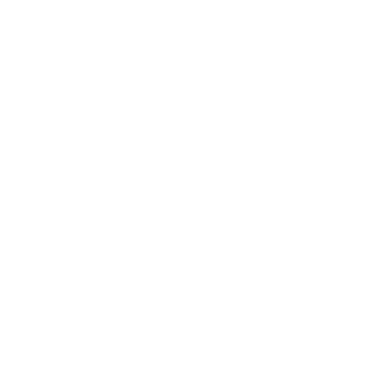

In [117]:
mask = np.full(rois.shape, np.nan, dtype=float)
stackview.imshow(mask)

In [121]:
# Indices you want
indices = [0, 1, 187]

# Extract the rows safely
try:
    selected = coordinates[indices]
    print(selected)
except IndexError as e:
    print(f"Error: {e}")
    print(f"Your array has {len(coordinates)} rows, so index 187 is out of bounds.")

[[10.25  5.25]
 [ 9.5  13.  ]
 [60.5  55.5 ]]


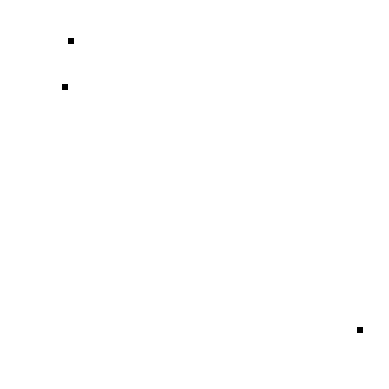

In [122]:
for (x, y) in selected.astype(int):
    if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
        mask[y, x] = 1

stackview.imshow(mask)

In [123]:
from djimaging.user.amacrine_cells_neuromodulation.image_visualisation import scale_bar_image

In [124]:
pixel_size = (Field() & {"date": date, "stim_name": stimulus, "cond2": condition, "field": field}).fetch("pixel_size_um")

print(f"Retrived pixel size of that field: {pixel_size}")

[2025-11-10 16:58:45,435][WARNING]: Reconnecting to MySQL server.


Retrived pixel size of that field: [1.71875]


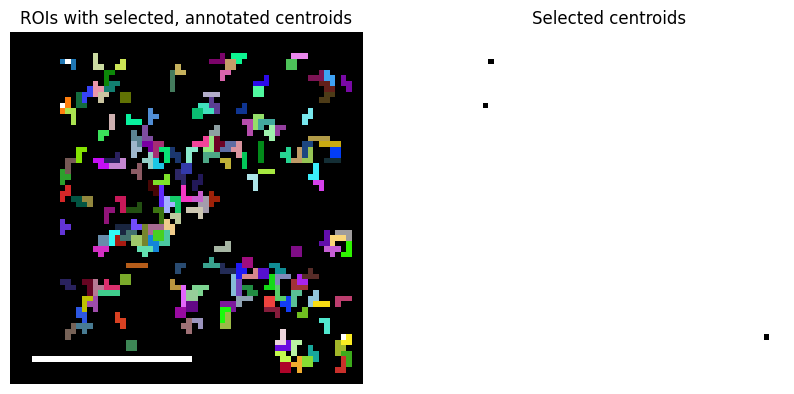

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

stackview.imshow(rois, labels=True, plot=axs[0])
stackview.imshow(mask, plot=axs[0], cmap="Grays")

scale_bar, cmap = scale_bar_image(rois, micron_length=pixel_size, scale_length=50, thickness=1)

stackview.imshow(scale_bar, plot=axs[0], cmap="Grays")

stackview.imshow(mask, plot=axs[1])

axs[0].set_title("ROIs with selected, annotated centroids")
axs[1].set_title("Selected centroids")

plt.savefig("plots/20251023/images/M1_RR_XY4_SelectedROIsAndCentroids.png",
            dpi=300,
            bbox_inches="tight")

In [141]:
distance_matrix = cdist(selected, selected, metric="euclidean")
distance_matrix = np.round(distance_matrix * pixel_size, 2)
distance_matrix

array([[  0.  ,  13.38, 122.14],
       [ 13.38,   0.  , 114.1 ],
       [122.14, 114.1 ,   0.  ]])

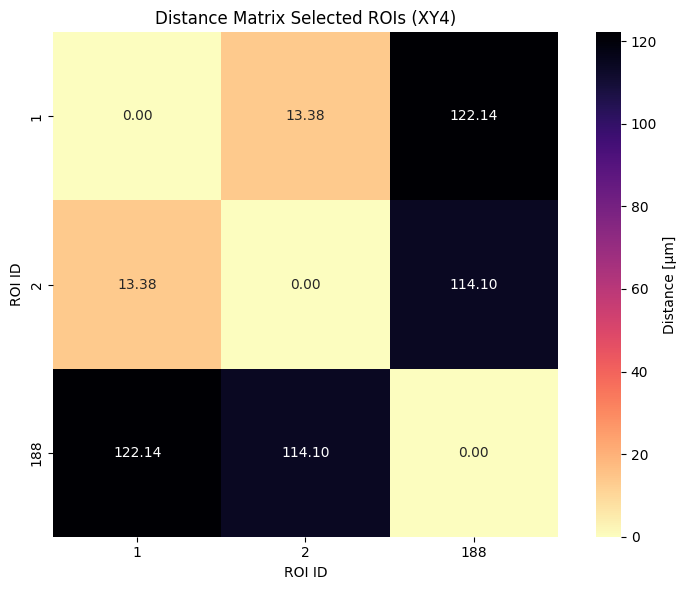

In [142]:
roi_ids = [i + 1 for i in indices]

plt.figure(figsize=(8, 6))

sns.heatmap(
    distance_matrix,
    cmap="magma_r",
    vmin=distance_matrix.min(),
    vmax=distance_matrix.max(),
    fmt=".2f",
    cbar_kws={"label": "Distance [µm]"},
    square=True,
    xticklabels=roi_ids,
    yticklabels=roi_ids,
    annot=True)

plt.title('Distance Matrix Selected ROIs (XY4)')
plt.xlabel("ROI ID")
plt.ylabel("ROI ID")
plt.tight_layout()

plt.savefig("plots/20251023/traces/M1_RR_XY4_selected_ROI_distance_matrix.png",
            dpi=300,
            bbox_inches="tight")

### For all ROIs

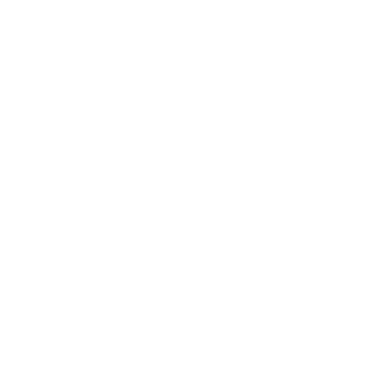

In [143]:
mask = np.full(rois.shape, np.nan, dtype=float)
stackview.imshow(mask)

In [144]:
mask

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(64, 64))

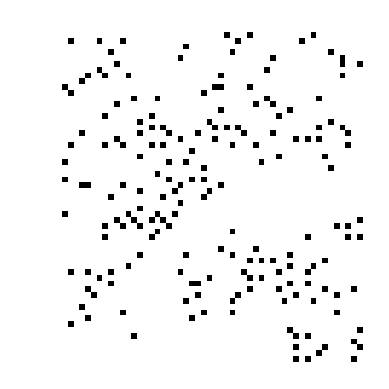

In [145]:
for (x, y) in coordinates.astype(int):
    if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
        mask[y, x] = 1

stackview.imshow(mask)

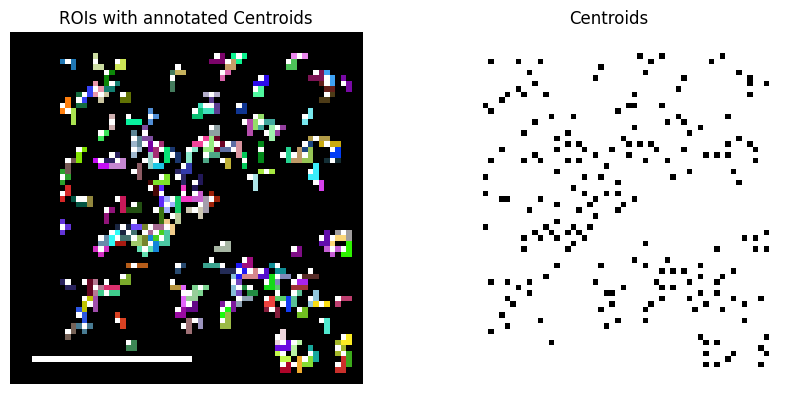

In [147]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

stackview.imshow(rois, labels=True, plot=axs[0])
stackview.imshow(mask, plot=axs[0], colormap="Grays")

scale_bar, cmap = scale_bar_image(rois, micron_length=pixel_size, scale_length=50, thickness=1)

stackview.imshow(scale_bar, plot=axs[0], colormap="Grays")

stackview.imshow(mask, plot=axs[1])

axs[0].set_title("ROIs with annotated Centroids")
axs[1].set_title("Centroids")

plt.savefig("plots/20251023/images/M1_RR_XY4_ROIsAndCentroids.png",
            dpi=300,
            bbox_inches="tight")

## Calculate distance matrix

In [148]:
distance_matrix = cdist(coordinates, coordinates, metric="euclidean")
distance_matrix

array([[ 0.        ,  7.78620575, 20.77408241, ..., 60.87897831,
        71.06423151, 73.56969485],
       [ 7.78620575,  0.        , 13.00240362, ..., 57.58146403,
        66.38712225, 68.69952693],
       [20.77408241, 13.00240362,  0.        , ..., 53.17718026,
        59.1338524 , 61.031242  ],
       ...,
       [60.87897831, 57.58146403, 53.17718026, ...,  0.        ,
        16.25192296, 19.5       ],
       [71.06423151, 66.38712225, 59.1338524 , ..., 16.25192296,
         0.        ,  3.2596012 ],
       [73.56969485, 68.69952693, 61.031242  , ..., 19.5       ,
         3.2596012 ,  0.        ]], shape=(189, 189))

In [149]:
# Calculate actual micrometers using pixel_size_um value
distance_matrix = distance_matrix * pixel_size
distance_matrix

array([[  0.        ,  13.38254113,  35.70545414, ..., 104.63574397,
        122.14164791, 126.44791302],
       [ 13.38254113,   0.        ,  22.34788123, ...,  98.9681413 ,
        114.10286636, 118.07731191],
       [ 35.70545414,  22.34788123,   0.        , ...,  91.39827857,
        101.63630882, 104.89744719],
       ...,
       [104.63574397,  98.9681413 ,  91.39827857, ...,   0.        ,
         27.93299259,  33.515625  ],
       [122.14164791, 114.10286636, 101.63630882, ...,  27.93299259,
          0.        ,   5.60243957],
       [126.44791302, 118.07731191, 104.89744719, ...,  33.515625  ,
          5.60243957,   0.        ]], shape=(189, 189))

In [150]:
distance_matrix.max()

np.float64(127.17878981999367)

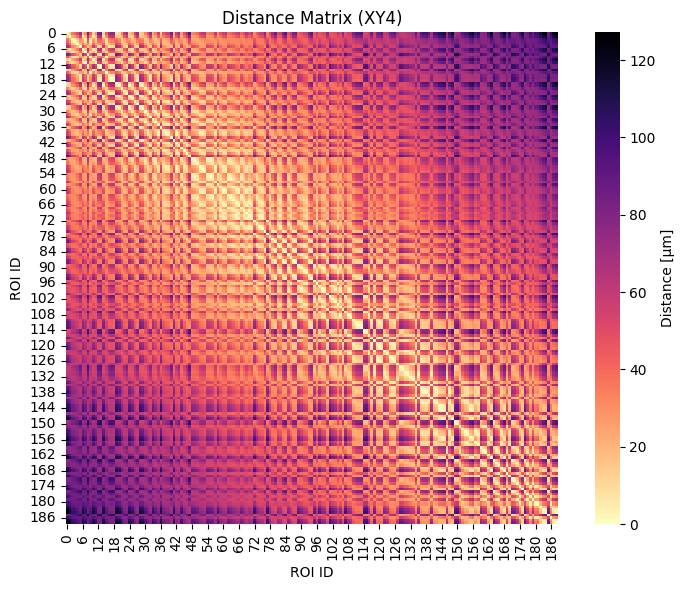

In [151]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    distance_matrix,
    cmap="magma_r",
    vmin=distance_matrix.min(),
    vmax=distance_matrix.max(),
    fmt=".2f",
    cbar_kws={"label": "Distance [µm]"},
    square=True)

plt.title('Distance Matrix (XY4)')
plt.xlabel("ROI ID")
plt.ylabel("ROI ID")
plt.tight_layout()

plt.savefig("plots/20251023/traces/M1_RR_XY4_ROI_distance_matrix.png",
            dpi=300,
            bbox_inches="tight")

# Map distances and correlations on images
- for visualisation purposes

In [152]:
correlations = correlation_coefficients[0]
distances = distance_matrix[0]

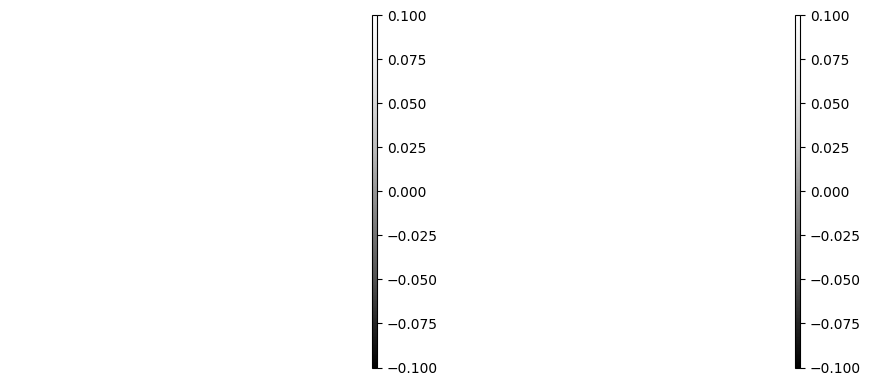

In [153]:
# Step 1: Create an output image initialized to zero (or np.nan)
correlation_map, distance_map = [np.full_like(rois, np.nan, dtype=float) for _ in range(2)]

fig, axs = plt.subplots(1, 2, figsize=(10,10))
stackview.imshow(correlation_map, plot=axs[0], colorbar=True)
stackview.imshow(distance_map, plot=axs[1], colorbar=True)

Text(0.5, 1.0, 'ROI 1 Distances')

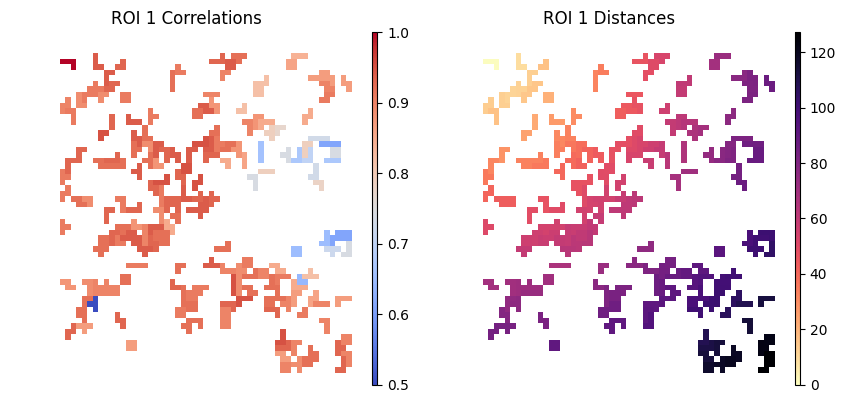

In [154]:
# Step 2: Replace label values with corresponding float distances
# Assuming labels start from 1 up to max_label
for label_id in range(1, rois.max() + 1):
    correlation_map[rois == label_id] = correlations[label_id - 1]
    distance_map[rois == label_id] = distances[label_id - 1]
    #roi_float_map[rois == label_id] = distances[label_id - 1]

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
stackview.imshow(correlation_map, colorbar=True, colormap="coolwarm", plot=axs[0])#, vmin=-1, vmax=1)
#stackview.imshow(correlation_map, colorbar=True, colormap="coolwarm", plot=axs[1], vmin=-1, vmax=1)
stackview.imshow(distance_map, colorbar=True, colormap="magma_r", plot=axs[1])

axs[0].set_title("ROI 1 Correlations")
axs[1].set_title("ROI 1 Distances")

In [168]:
def map_correlations_distances_on_rois(
    roi_mask,
    correlation_matrix,
    distance_matrix,
    roi_id=0,
    minimum_correlation=False):

    correlations = correlation_matrix[roi_id]
    distances = distance_matrix[roi_id]

    # Step 1: Create an output image initialized to zero (or np.nan)
    correlation_map, distance_map = [np.full_like(roi_mask, np.nan, dtype=float) for _ in range(2)]

    # Step 2: Replace label values with corresponding float distances
    # Assuming labels start from 1 up to max_label
    for label_id in range(1, roi_mask.max() + 1):
        correlation_map[roi_mask == label_id] = correlations[label_id - 1]
        distance_map[roi_mask == label_id] = distances[label_id - 1]

    fig, axs = plt.subplots(1, 2, figsize=(10, 10))

    if minimum_correlation == True:
        stackview.imshow(correlation_map, colorbar=True, colormap="coolwarm", plot=axs[0], min_display_intensity=np.min(correlation_matrix))
        stackview.imshow(distance_map, colorbar=True, colormap="magma_r", plot=axs[1])
    else:   
        stackview.imshow(correlation_map, colorbar=True, colormap="coolwarm", plot=axs[0])
        stackview.imshow(distance_map, colorbar=True, colormap="magma_r", plot=axs[1])
    
    axs[0].set_title(f"ROI {roi_id + 1} Correlations")
    axs[1].set_title(f"ROI {roi_id + 1} Distances")

In [169]:
np.min(correlation_coefficients)

np.float64(0.06)

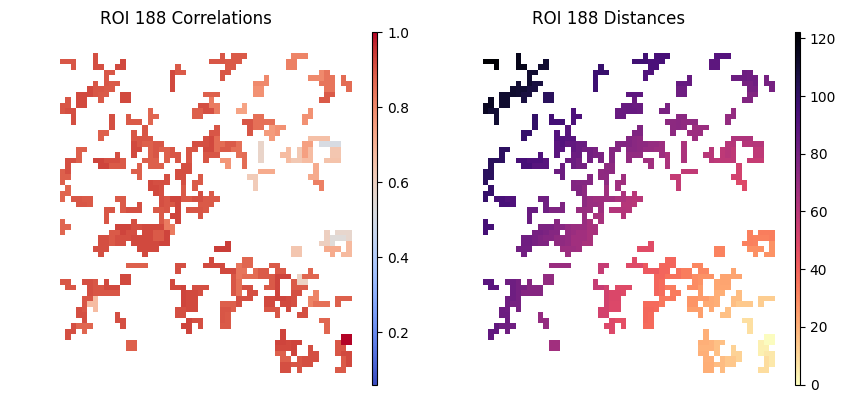

In [179]:
roi = 187
map_correlations_distances_on_rois(roi_mask=rois,
                                   correlation_matrix=correlation_coefficients,
                                   distance_matrix=distance_matrix,
                                   roi_id=roi,
                                   minimum_correlation=True)

plt.savefig(f"plots/20251023/images/M1_RR_XY4_ROI{roi + 1}_corrdistmap.png",
            dpi=300,
            bbox_inches="tight")

# Sort values in correlation and distance matrix

- hypothesis: clusters which are near in space to each other and show similar responses
- values can be sorted with the same sort index used for the heatmap of the traces

In [180]:
print(f"Sort indices: {sort_idxs}")

Sort indices: [ 18 173 180 181 157 174 132 152 151 177 165 127 161 179 186 146 178 166
 133 140 160 169 118  13 135  47   5   3 129   2 159 162   4 156 145 167
 109 150 139 154 182  46 128  23  15  71 164  65  27  16 149  24 170 153
  17   1   9 112  37 176 113  51  11 185 148 120  32  30  35  20  63 163
 171 147  31 175 168  12  57   8 110 131  29 119  39  93 172   7  68  10
 188  80  14  26 138  87   6  38 130 102 183  55 187  88  43 137 142 134
 184  25  58 123  67  83  94 155  50 116  33  84 158  53 125 124  42  34
  77 136 144 101  21   0  19 141  56 111  40  48  49  62  66  44  73  59
  78  86  69  97 107  28 122 126  64 115  45 105 100  36  76 114  22  79
  52 117  85  75  82  60  54  96 106 121  61 143  92  70 108  41 104  89
  91  90  72 103  81  95  74  99  98]


In [181]:
print(f"Correlation matrix: {correlation_coefficients}")
print(f"Distance matrix: {distance_matrix}")

Correlation matrix: [[1.   0.9  0.91 ... 0.74 0.9  0.9 ]
 [0.9  1.   0.93 ... 0.58 0.9  0.9 ]
 [0.91 0.93 1.   ... 0.54 0.88 0.89]
 ...
 [0.74 0.58 0.54 ... 1.   0.68 0.7 ]
 [0.9  0.9  0.88 ... 0.68 1.   0.92]
 [0.9  0.9  0.89 ... 0.7  0.92 1.  ]]
Distance matrix: [[  0.          13.38254113  35.70545414 ... 104.63574397 122.14164791
  126.44791302]
 [ 13.38254113   0.          22.34788123 ...  98.9681413  114.10286636
  118.07731191]
 [ 35.70545414  22.34788123   0.         ...  91.39827857 101.63630882
  104.89744719]
 ...
 [104.63574397  98.9681413   91.39827857 ...   0.          27.93299259
   33.515625  ]
 [122.14164791 114.10286636 101.63630882 ...  27.93299259   0.
    5.60243957]
 [126.44791302 118.07731191 104.89744719 ...  33.515625     5.60243957
    0.        ]]


In [182]:
# Sort correlation and distance matrix
correlation_coefficients_sorted = correlation_coefficients[sort_idxs, :][:, sort_idxs]
distance_matrix_sorted = distance_matrix[sort_idxs, :][:, sort_idxs]
print(f"Sorted correlation matrix: {correlation_coefficients_sorted}")
print(f"Sorted distance matrix: {distance_matrix_sorted}")

Sorted correlation matrix: [[1.   0.06 0.14 ... 0.63 0.52 0.57]
 [0.06 1.   0.92 ... 0.58 0.65 0.64]
 [0.14 0.92 1.   ... 0.6  0.65 0.65]
 ...
 [0.63 0.58 0.6  ... 1.   0.96 0.97]
 [0.52 0.65 0.65 ... 0.96 1.   0.97]
 [0.57 0.64 0.65 ... 0.97 0.97 1.  ]]
Sorted distance matrix: [[ 0.         88.78741268 78.27509995 ... 40.6026268  58.45171587
  61.1923881 ]
 [88.78741268  0.         29.72617752 ... 51.14905861 37.58230713
  37.38528189]
 [78.27509995 29.72617752  0.         ... 51.08042879 47.19526012
  49.15745191]
 ...
 [40.6026268  51.14905861 51.08042879 ...  0.         17.88243535
  20.78550826]
 [58.45171587 37.58230713 47.19526012 ... 17.88243535  0.
   3.4375    ]
 [61.1923881  37.38528189 49.15745191 ... 20.78550826  3.4375
   0.        ]]


In [183]:
labels = np.arange(len(sort_idxs))
labels

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

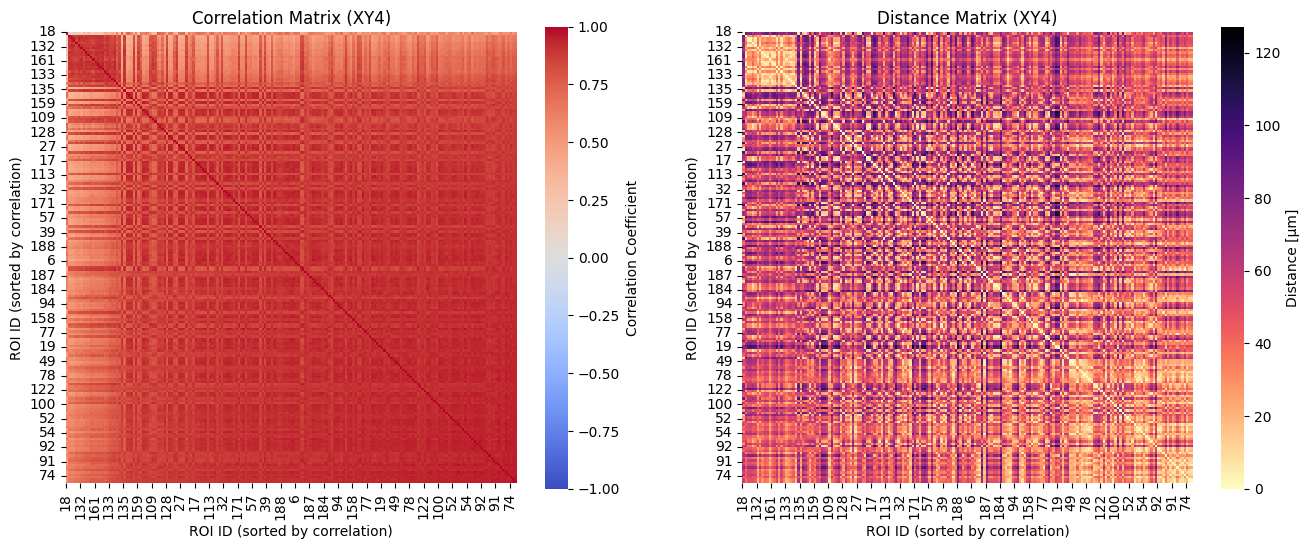

In [184]:
sorted_labels = [labels[i] for i in sort_idxs]

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

#plt.figure(figsize=(8, 6))  # adjust size as needed
sns.heatmap(
    correlation_coefficients_sorted, 
    cmap='coolwarm',          # color map (try also 'viridis', 'RdBu_r', etc.)
    vmin=-1, vmax=1,          # correlation ranges from -1 to 1
    square=True,              # make cells square
    #annot=True,               # show correlation values in cells
    fmt=".2f",                # format the annotations
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=axs[0])

axs[0].set_title('Correlation Matrix (XY4)')
axs[0].set_xlabel("ROI ID (sorted by correlation)")
axs[0].set_ylabel("ROI ID (sorted by correlation)")

sns.heatmap(
    distance_matrix_sorted,
    cmap="magma_r",
    vmin=distance_matrix.min(),
    vmax=distance_matrix.max(),
    fmt=".2f",
    cbar_kws={"label": "Distance [µm]"},
    square=True,
    ax=axs[1])

axs[1].set_title('Distance Matrix (XY4)')
axs[1].set_xlabel("ROI ID (sorted by correlation)")
axs[1].set_ylabel("ROI ID (sorted by correlation)")

for j in range(2):
    # Apply sorted labels
    axs[j].set_xticks(np.arange(len(sorted_labels)))
    axs[j].set_yticks(np.arange(len(sorted_labels)))
    axs[j].set_xticklabels(sorted_labels, rotation=90)
    axs[j].set_yticklabels(sorted_labels, rotation=0)
    
    # Only show every nth label and set corresponding ticks
    every_nth = 6
    xtick_positions = np.arange(0, len(sorted_labels), every_nth)
    ytick_positions = np.arange(0, len(sorted_labels), every_nth)
    
    axs[j].set_xticks(xtick_positions)
    axs[j].set_yticks(ytick_positions)
    
    axs[j].set_xticklabels([sorted_labels[i] for i in xtick_positions], rotation=90)
    axs[j].set_yticklabels([sorted_labels[i] for i in ytick_positions], rotation=0)

plt.savefig("plots/20251023/traces/M1_RR_XY4_sorted_corrdistmatrix.png",
            dpi=300,
            bbox_inches="tight")

# Filter matrices based on correlation and distance
- if correlation between two ROIs > 0.75 and distance < 10 µm: 1
- else: 0

In [185]:
from matplotlib.colors import ListedColormap

In [186]:
filter_correlation = 0.8
filter_distance = 10

# Filter matrices based on values
binarised_matrix_sorted = np.where((correlation_coefficients_sorted > filter_correlation) &
                            (distance_matrix_sorted < filter_distance), 1, 0)

binarised_matrix_sorted

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1]], shape=(189, 189))

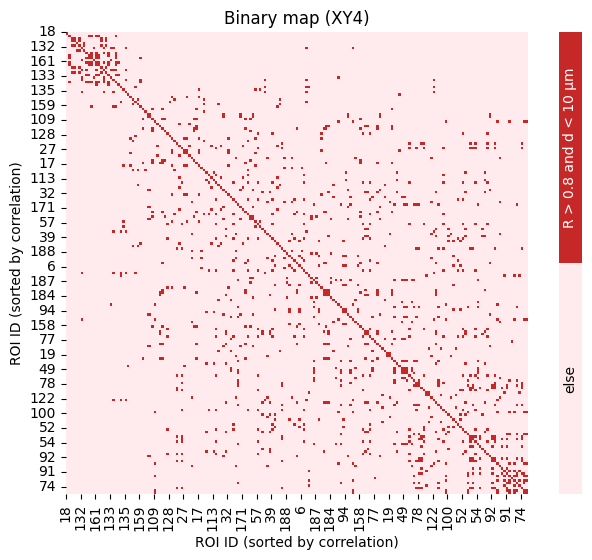

In [187]:
plt.figure(figsize=(8, 6))  # adjust size as needed

cmap = ListedColormap(["#FFEBEE", "#C62828"])

axs = sns.heatmap(
    binarised_matrix_sorted, 
    cmap=cmap,          # color map (try also 'viridis', 'RdBu_r', etc.)
    vmin=0, vmax=1,          # correlation ranges from -1 to 1
    square=True,              # make cells square
    #annot=True,               # show correlation values in cells
    fmt=".2f")                # format the annotations)

# Apply sorted labels
axs.set_xticks(np.arange(len(sorted_labels)))
axs.set_yticks(np.arange(len(sorted_labels)))
axs.set_xticklabels(sorted_labels, rotation=90)
axs.set_yticklabels(sorted_labels, rotation=0)

# Only show every nth label and set corresponding ticks
every_nth = 6
xtick_positions = np.arange(0, len(sorted_labels), every_nth)
ytick_positions = np.arange(0, len(sorted_labels), every_nth)

axs.set_xticks(xtick_positions)
axs.set_yticks(ytick_positions)

axs.set_xticklabels([sorted_labels[i] for i in xtick_positions], rotation=90)
axs.set_yticklabels([sorted_labels[i] for i in ytick_positions], rotation=0)

axs.set_title(f"Binary map (XY4)")
axs.set_xlabel("ROI ID (sorted by correlation)")
axs.set_ylabel("ROI ID (sorted by correlation)")

cbar = axs.collections[0].colorbar  # get the colorbar associated with the heatmap
cbar.set_ticks([])

# Add custom text
# Get colorbar position
cbar_ax = cbar.ax
# Add text to upper half
cbar_ax.text(0.5, 0.75, f"R > {filter_correlation} and d < {filter_distance} µm",
             ha='center', va='center', fontsize=10, rotation=90, color='white', transform=cbar_ax.transAxes)
# Add text to lower half
cbar_ax.text(0.5, 0.25, "else",
             ha='center', va='center', fontsize=10, rotation=90, color='black', transform=cbar_ax.transAxes)

plt.savefig("plots/20251023/traces/M1_RR_XY4_gChirp_binary_heatmap_sorted.png",
            dpi=300,
            bbox_inches="tight")

In [188]:
# Filter matrices based on values
binarised_matrix = np.where((correlation_coefficients > filter_correlation) &
                            (distance_matrix < filter_distance), 1, 0)

binarised_matrix

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1]], shape=(189, 189))

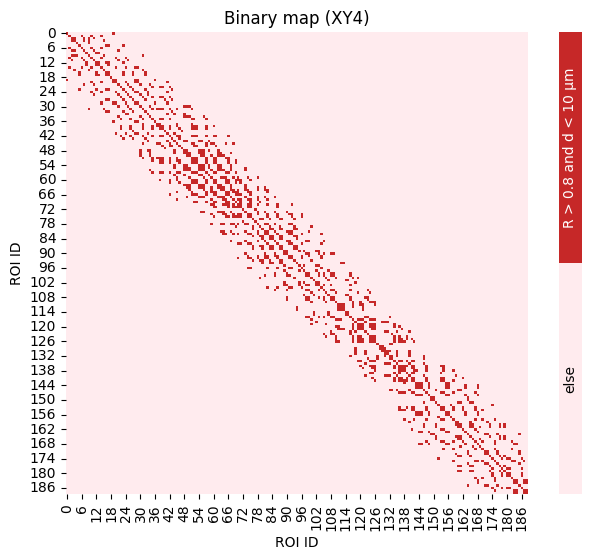

In [189]:
plt.figure(figsize=(8, 6))  # adjust size as needed

cmap = ListedColormap(["#FFEBEE", "#C62828"])

axs = sns.heatmap(
    binarised_matrix, 
    cmap=cmap,          # color map (try also 'viridis', 'RdBu_r', etc.)
    vmin=0, vmax=1,          # correlation ranges from -1 to 1
    square=True,              # make cells square
    #annot=True,               # show correlation values in cells
    fmt=".2f")                # format the annotations)

axs.set_title(f"Binary map (XY4)")
axs.set_xlabel("ROI ID")
axs.set_ylabel("ROI ID")

cbar = axs.collections[0].colorbar  # get the colorbar associated with the heatmap
cbar.set_ticks([])

# Add custom text
# Get colorbar position
cbar_ax = cbar.ax
# Add text to upper half
cbar_ax.text(0.5, 0.75, f"R > {filter_correlation} and d < {filter_distance} µm",
             ha='center', va='center', fontsize=10, rotation=90, color='white', transform=cbar_ax.transAxes)
# Add text to lower half
cbar_ax.text(0.5, 0.25, "else",
             ha='center', va='center', fontsize=10, rotation=90, color='black', transform=cbar_ax.transAxes)

plt.savefig("plots/20251023/traces/M1_RR_XY4_gChirp_binary_heatmap_unsorted.png",
            dpi=300,
            bbox_inches="tight")